# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Lokeshtiwari723/Proto-ex/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
## Research Question

**Research question:** Which observable search and content signals can help us rank pages that should be reviewed first?

The goal is to create a ranked review queue that helps a content or SEO reviewer decide which pages to inspect first. The output is decision-support, not a final judgment about whether a page is failing.

The analysis uses observable February 2026 page-level signals and a March 2026 proxy outcome to measure whether the signals contain useful information for review prioritization.

In [8]:
research_question = (
    "Which observable search and content signals can help us "
    "rank pages that should be reviewed first?"
)

decision_supported = (
    "Prioritize pages for human review based on observable "
    "search and content signals."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Which observable search and content signals can help us rank pages that should be reviewed first?

Decision supported:
Prioritize pages for human review based on observable search and content signals.


## 2. Data


The analysis uses the FlyRank ML Internship warehouse data for a February 2026 feature window and a March 2026 label window.

One row represents one page-level search/content record identified by a client-content pair.

For the model, the February feature set uses:
- GSC impressions
- GSC clicks
- GSC average position
- Word count
- Content age in days

The March outcome is a proxy label based on March CTR relative to the median March CTR cutoff. Pages without sufficient March impressions for the label calculation are excluded.

Future March outcome fields are not used as model features. Client and content identifiers are used only for grouping and joining, not as predictive features.

The analysis is intended for review prioritization and does not establish causal effects.

In [9]:
print("Feature window: February 2026")
print("Label window: March 2026")

print("\nModel features:")
for feature in [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "word_count",
    "content_age_days",
]:
    print("-", feature)

print("\nLabel:")
print("March CTR > March CTR median cutoff")

print("\nFuture March outcome fields used as features: NO")
print("Client/content IDs used as predictive features: NO")

Feature window: February 2026
Label window: March 2026

Model features:
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- word_count
- content_age_days

Label:
March CTR > March CTR median cutoff

Future March outcome fields used as features: NO
Client/content IDs used as predictive features: NO


## 3. Methodology

The first model is Logistic Regression because it is simple, interpretable, and suitable for checking whether the selected observable signals contain useful information for ranking review priority.

The model uses five February 2026 features:
- GSC impressions
- GSC clicks
- GSC average position
- Word count
- Content age in days

The March label is a proxy outcome based on whether a page's March CTR is above the median March CTR cutoff.

The Week-4 baseline is a transparent action score based on visibility and content age. The model and baseline are evaluated using Precision@50 on the same held-out test set.

Validation uses a client-grouped split so that clients do not overlap between training and test data. The measured client overlap was zero.

A leakage audit excludes future March outcome fields, label-derived fields, and identifiers from the predictive feature set.

This analysis supports review prioritization. It does not establish causation or guarantee future performance.

In [10]:
import pandas as pd

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "word_count",
    "content_age_days",
]

method_summary = pd.DataFrame({
    "Item": [
        "Model",
        "Baseline",
        "Features",
        "Validation",
        "Metric",
        "Client overlap",
        "Leakage status",
    ],
    "Value": [
        "Logistic Regression",
        "Week-4 action score",
        "5 February 2026 observable features",
        "Client-grouped 80/20 holdout",
        "Precision@50",
        "0",
        "Passed",
    ],
})

display(method_summary)

,Item,Value
0,Model,Logistic Regression
1,Baseline,Week-4 action score
2,Features,5 February 2026 observable features
3,Validation,Client-grouped 80/20 holdout
4,Metric,Precision@50
5,Client overlap,0
6,Leakage status,Passed


## 4. Results (vs baseline)


On the held-out client-grouped test set, the Logistic Regression model measured Precision@50 of 1.00, while the Week-4 action-score baseline measured Precision@50 of 0.76.

This means all 50 pages selected in the model's top-50 queue were positive under the March proxy label in this test split, compared with 38 positive pages among the baseline's top 50.

The result is evidence of useful ranking signal in this test setup. It should not be interpreted as a guarantee of future performance or as evidence of causation.

The model was also selective: many positive pages remained outside the top 50, so the queue should be treated as a prioritization tool rather than a complete list of pages needing attention.

In [11]:
comparison = pd.DataFrame({
    "Method": [
        "Week-4 action-score baseline",
        "Logistic Regression"
    ],
    "Precision@50": [
        0.76,
        1.00
    ],
    "Positive pages in Top 50": [
        38,
        50
    ],
})

display(comparison)

print("Evaluation metric: Precision@50")
print("Model test setup: client-grouped held-out split")

,Method,Precision@50,Positive pages in Top 50
0,Week-4 action-score baseline,0.76,38
1,Logistic Regression,1.00,50


Evaluation metric: Precision@50
Model test setup: client-grouped held-out split


## 5. Limitations


This work has several important limits.

1. The March outcome is a proxy label based on March CTR relative to the median cutoff. It is not a direct measure of business success.

2. Precision@50 was measured on one held-out client-grouped test split. The result should not be treated as a guarantee for future data.

3. The model is designed to prioritize a small review queue. Many positive pages remained outside the top 50, so the model does not identify every page that may deserve review.

4. The observable signals describe page performance and content characteristics. They do not establish that changing a feature will cause the March outcome to change.

5. GSC availability is not uniform across all records, so the analysis represents the available observable data rather than every possible page record.

6. Human review is still required before taking a content action. The ranking is decision-support, not an automated final decision.

In [12]:
limitations_check = pd.DataFrame({
    "Check": [
        "Proxy label rather than direct business outcome",
        "Single held-out grouped test split",
        "Top-50 queue is selective",
        "No causal claim",
        "GSC availability is uneven",
        "Human review required",
    ],
    "Status": [
        "Documented",
        "Documented",
        "Documented",
        "Documented",
        "Documented",
        "Required",
    ],
})

display(limitations_check)

,Check,Status
0,Proxy label rather than direct business outcome,Documented
1,Single held-out grouped test split,Documented
2,Top-50 queue is selective,Documented
3,No causal claim,Documented
4,GSC availability is uneven,Documented
5,Human review required,Required


## 6. Ranked recommendations

The model output is used as a review-prioritization queue.

### 1. Review for refresh

Pages with high model priority and strong baseline visibility should be reviewed first for possible content refresh.

The reviewer should inspect the page, search intent, current content quality, and recent performance before making a change.

### 2. Review opportunity

Pages with high model priority but a different baseline action should be reviewed as potential search-performance opportunities.

The model score alone should not determine the action.

### 3. General review

Lower-priority pages can remain in the queue for later review when review capacity is available.

### Human decision rule

The model ranks pages; a human decides whether an actual content change is appropriate.

In [13]:
recommendations = pd.DataFrame({
    "Priority": [1, 2, 3],
    "Action": [
        "Review for refresh",
        "Review opportunity",
        "General review",
    ],
    "Reason": [
        "High model priority plus strong baseline visibility",
        "High model priority requiring contextual review",
        "Lower priority for later human review",
    ],
    "Automation": [
        "Do not automate final action",
        "Do not automate final action",
        "Do not automate final action",
    ],
})

display(recommendations)

,Priority,Action,Reason,Automation
0,1,Review for refresh,High model priority plus strong baseline visib...,Do not automate final action
1,2,Review opportunity,High model priority requiring contextual review,Do not automate final action
2,3,General review,Lower priority for later human review,Do not automate final action


## 7. Artifacts the paper embeds


The paper will use a small set of transparent tables and figures rather than presenting the model as a black box.

The main result artifact is the Precision@50 comparison between the Week-4 baseline and Logistic Regression.

The recommendation artifact summarizes the three human-review actions used by the action playbook.

These artifacts are descriptive of the measured test setup and are intended to make the research result easy to inspect.

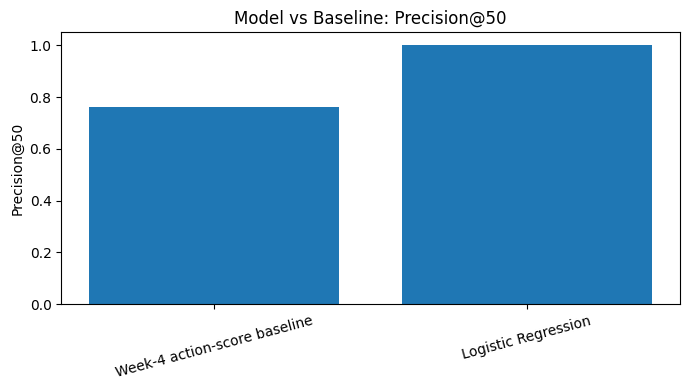

Figure saved: work/figures/model_vs_baseline_precision_at_50.png
Recommendation table saved: work/figures/ranked_recommendations.csv


In [14]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# Paper-ready model vs baseline figure
plot_df = comparison.copy()

plt.figure(figsize=(7, 4))
plt.bar(plot_df["Method"], plot_df["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Model vs Baseline: Precision@50")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()

figure_path = "work/figures/model_vs_baseline_precision_at_50.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

# Paper-ready recommendation table
recommendation_path = "work/figures/ranked_recommendations.csv"
recommendations.to_csv(recommendation_path, index=False)

print("Figure saved:", figure_path)
print("Recommendation table saved:", recommendation_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
